# 26 — Calculate the Residual Risk Add-on

Classify qualifying residual risks and apply the charge to gross notional without netting.

The Residual Risk Add-on (RRAO) is additional to SBM and DRC. Exotic underlyings use 1.0%; other residual risks use 0.1%. Long and short trades do not offset.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260901T122303Z


This is the part of the calculation chain being handled here:

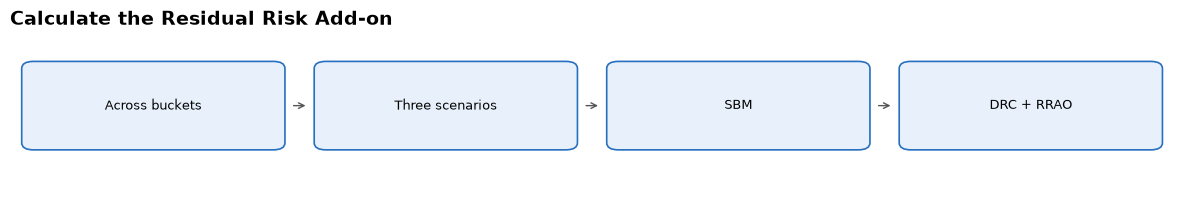

In [2]:
draw_flow(['Across buckets', 'Three scenarios', 'SBM', 'DRC + RRAO'],'Calculate the Residual Risk Add-on',wrap_after=4)

Translate gross notional to INR and multiply it by the applicable residual-risk weight.

$$RRAO_i=|\text{gross notional}_{i,INR}|\times RW_i$$

In [3]:
detail=pd.read_csv(RUN/'15_rrao_detail.csv')
columns=['trade_id','desk','instrument_type','rrao_type','classification_reason','gross_notional_inr','risk_weight','rrao_charge']
display(percent_columns(crore_table(detail[columns],['gross_notional_inr','rrao_charge']),['risk_weight']))
print(f"Total RRAO: INR {detail.rrao_charge.sum()/INR_CRORE:,.4f} crore")

,trade_id,desk,instrument_type,rrao_type,classification_reason,Gross Notional (INR crore),Risk Weight (%),Rrao Charge (INR crore)
0,C08,Credit,CALLABLE_BOND,OTHER_RESIDUAL_RISK,embedded_callability,9.3400,0.1000,0.0093
1,E10,Equity,BARRIER_OPTION,OTHER_RESIDUAL_RISK,path_dependent_barrier,37.1250,0.1000,0.0371
2,F05,FX,DIGITAL_OPTION,OTHER_RESIDUAL_RISK,discontinuous_digital_payoff,0.1000,0.1000,0.0001
3,X01,Residual Risk,WEATHER_DERIVATIVE,EXOTIC_UNDERLYING,weather_underlying_outside_sbm_drc,5.0000,1.0000,0.0500
4,X02,Residual Risk,REALIZED_VOL_SWAP,EXOTIC_UNDERLYING,future_realized_volatility_underlying,3.0000,1.0000,0.0300


Total RRAO: INR 0.1266 crore


The visual below uses the calculated rows shown above.

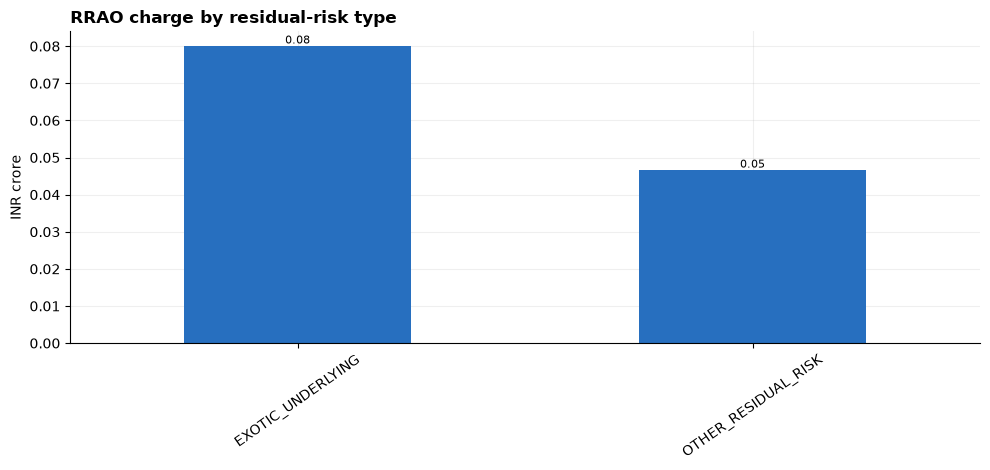

In [4]:
bar_crore(detail.groupby('rrao_type')['rrao_charge'].sum(),'RRAO charge by residual-risk type')

RRAO is added without diversification against SBM or DRC.